# Autovakuutustuotteen lanseerauksen kriittisen polun aikataulutus

## Tiivistelmä johdolle

Henkilöautovakuutustuotteen lanseeraus on toimintojen rajat ylittävä ohjelma: aktuaarit hinnoittelevat riskin, säädöstenmukaisuus toimittaa hinnat osavaltiolle ja odottaa hyväksyntää, IT konfiguroi vakuutushallintajärjestelmän ja jakelu kouluttaa edustajat. Näillä tehtävillä on kiinteät järjestyssuhteet, joten lanseerauspäivän määrää suunnitelman pisin riippuvuusketju -- **kriittinen polku**.

Tämä muistikirja rakentaa toiminto-solmuina (Activity-on-Node) esitetyn projektiverkon yhdestätoista lanseeraustehtävästä ja laskee täyden **kriittisen polun menetelmän (CPM)** aikataulun **PROC OPTMODEL** -proseduurilla. CPM:n eteen- ja taaksepäin suoritetut vaiheet ovat lineaarisia optimointitehtäviä järjestysgraafissa: eteenpäinvaihe (pisin polku alusta) antaa kunkin tehtävän aikaisimman aloituksen ja lopetuksen, ja taaksepäin suoritettu pisimmän polun vaihe antaa myöhäisimmän aloituksen ja lopetuksen sekä **kokonaispelivaran** (aikataulun väljyys). Alla olevat tulokset tuottaa kokonaisuudessaan tämän muistikirjan koodi -- jokainen kertomuksen luku luetaan takaisin suoritetusta tulosteesta.

**Mitä aikataulu osoittaa.** Viiden päivän työkalenterilla, joka on ankkuroitu päivään 01JUN2026, ohjelma kestää **97 työpäivää** ja valmistuu **13OCT2026**. Yhdeksän yhdestätoista tehtävästä on kriittisellä polulla (Aloitus -> Markkinatutkimus -> Vahinkotietojen kokoaminen -> Hinnoittelu -> Järjestelmäsuunnittelu -> Järjestelmän rakentaminen -> UAT -> Edustajien koulutus -> Lanseeraus) ja niiden pelivara on nolla. Vain sääntelyhaaralla -- **hintailmoituksella** ja **hyväksynnällä** -- on väljyyttä: kumpikin voi liukua enintään **30 työpäivää** siirtämättä lanseerausta, koska rinnakkainen järjestelmän rakennushaara on kahdesta yhtyvästä polusta pidempi.

## Kuinka tämä on rakennettu

CPM on perinteisesti SAS/OR-proseduuri, mutta sen ydinlaskenta on pari pisimmän polun ongelmaa järjestysgraafissa, jotka PROC OPTMODEL ilmaisee suoraan pieninä lineaarisina optimointitehtävinä:

- **Eteenpäinvaihe (aikaisimmat ajat).** Minimoi aikaisimman aloituksen muuttujat ehdolla `ES[successor] >= ES[predecessor] + duration + lag` jokaiselle järjestyskaarelle. Optimissa kukin `ES` on yhtä suuri kuin pisin polku projektin alusta, eli aikaisin hetki, jolloin tehtävä voi alkaa.
- **Taaksepäinvaihe (myöhäisimmät ajat / pelivara).** Laske kullekin tehtävälle pisin jäljellä oleva polku projektin loppuun (`TAIL`). Myöhäisin aloitus on tällöin `makespan - TAIL`, ja **kokonaispelivara** on `late start - early start`. Tehtävät, joiden pelivara on nolla, ovat kriittisiä.

Verkko, kestot, järjestysten viiveet ja tehtäväkohtaiset resurssitarpeet luodaan kaikki koodissa suoraan; ulkoisia syötteitä ei ole. Työpäiväkalenteripäivät johdetaan `INTNX('weekday', ...)` -funktiolla, joten viikonloput ohitetaan.

## Aineisto

| Aineisto | Rivejä | Avainmuuttujat | Kuvaus |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Toimintojen perustiedot: kukin lanseeraustehtävä, sen kesto työpäivinä ja sen tarvitsema päivittäinen aktuaari- / kehittäjämäärä |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Toiminto-solmu-verkon järjestyskaaret; `lag` on lopetus-aloitus-viive työpäivinä (sääntelyn odotusaika hyväksynnän jälkeen) |

Numeeriset toimintotunnisteet toimivat verkon avaimina, jotta järjestysgraafi luetaan siististi OPTMODELin tuple-joukkoon; luettavat `activity`-nimet liitetään aikatauluun takaisin jälkeenpäin.

In [1]:
TIEDOT acts;
   PITUUS activity $32;
   INFILE DATALINES DSD DLM=',';
   SYÖTE id activity $ dur actuary developer;
   DATALINES;
1,Aloitus,3,1,0
2,Markkinatutkimus,8,2,0
3,Vahinkotietojen kokoaminen,10,3,0
4,Hinnoittelu,9,3,1
5,Hintailmoitus,4,1,0
6,Hyväksyntä,6,1,0
7,Järjestelmäsuunnittelu,12,1,2
8,Järjestelmän rakentaminen,18,0,3
9,UAT,15,0,2
10,Edustajien koulutus,20,1,1
11,Lanseeraus,2,1,1
;
SUORITA;

TIEDOT arcs;
   SYÖTE pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
SUORITA;

/* Pelkästään numeerinen näkymä kestoista OPTMODELia varten */
TIEDOT acts_n; ASETA acts; SÄILYTÄ id dur; SUORITA;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Eteenpäinvaihe -- aikaisin aloitus ja lopetus

Eteenpäinvaihe on pisimmän polun optimointitehtävä. Ehto `ES[j] >= ES[i] + dur[i] + lag[i,j]` jokaiselle kaarelle pakottaa kunkin tehtävän alkamaan aikaisintaan silloin, kun kaikki sen edeltäjät valmistuvat (plus mahdollinen sääntelyviive); aikaisimman aloituksen muuttujien minimointi ajaa kunkin pisimmälle edeltäjäpolulleen. Kirjoitamme ratkaistut `ES`-arvot suoraan OPTMODEL-muuttujasta `fwd`-aineistoon.

In [2]:
PROSEDUURI optmodel;
   set NODES; num dur{NODES};
   read data acts_n into NODES=[id] dur=dur;

   set <num,num> ARCS; num lag{ARCS};
   read data arcs into ARCS=[pred succ] lag=lag;

   var ES{NODES} >= 0;
   con prec{<i,j> in ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   min total_es = sum{k in NODES} ES[k];
   solve;

   create data fwd from [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Taaksepäinvaihe -- myöhäisimmät ajat ja kokonaispelivara

`TAIL[a]` on pisin polku tehtävästä `a` projektin loppuun asti, joten sen on katettava tehtävän oma kesto ja jokaiselle seuraajalle viive plus kyseisen seuraajan häntä: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Häntien minimointi tuottaa tiukimmat tällaiset arvot. Projektin **kokonaiskesto (makespan)** on suurin aikaisin lopetus; kunkin tehtävän **myöhäisin aloitus** on `makespan - TAIL`, ja **kokonaispelivara** on `late start - early start`. Nollan pelivara merkitsee kriittistä polkua.

In [3]:
PROSEDUURI optmodel;
   set NODES; num dur{NODES};
   read data acts_n into NODES=[id] dur=dur;

   set <num,num> ARCS; num lag{ARCS};
   read data arcs into ARCS=[pred succ] lag=lag;

   var TAIL{NODES} >= 0;
   con base{a in NODES}: TAIL[a] >= dur[a];
   con back{<i,j> in ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   min total_tail = sum{k in NODES} TAIL[k];
   solve;

   create data bwd from [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Aikataulun ja kalenterin kokoaminen

Liitämme aikaisimmat aloitukset ja hännät takaisin toimintojen perustietoihin, johdamme myöhäisimmän aloituksen / lopetuksen ja kokonaispelivaran sekä kuvaamme työpäiväsiirtymät kalenteripäiviksi `INTNX('weekday', ...)` -funktiolla, jotta päivät osuvat arkipäiville. Tehtävä merkitään **kriittiseksi**, kun sen kokonaispelivara on nolla.

In [4]:
%LET anchor = '01jun2026'd;

TIEDOT sched0;
   YHDISTÄ acts fwd bwd; MUKAAN id;
   ef = es + dur;            /* aikaisin lopetus */
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=sched0 NOPRINT;
   TULOSTE out=mk(POISTA=_type_ _freq_) MAX(ef)=makespan;
SUORITA;

TIEDOT sched;
   JOS _n_=1 NIIN ASETA mk;
   ASETA sched0;
   PIDÄ mspan;
   JOS _n_=1 NIIN mspan = makespan;
   ls = mspan - tail;        /* myöhäisin aloitus */
   lf = ls + dur;            /* myöhäisin lopetus */
   tfloat = ls - es;         /* kokonaispelivara  */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   PITUUS cclass $12;
   JOS critical NIIN cclass='Kriittinen';
   MUUTEN cclass='Pelivara';
   MUOTO e_start e_finish l_start l_finish date9.;
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=sched out=sched_es; MUKAAN es id; SUORITA;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## CPM-aikataulu

Aikaisin/myöhäisin aloitus ja lopetus ovat työpäivinä 01JUN2026-ankkurista (päivä 0). Tehtävillä **Kriittinen**-luokassa on nollan kokonaispelivara.

In [5]:
OTSIKKO 'CPM-aikataulu -- työpäiväajat ja kokonaispelivara';
PROSEDUURI TULOSTA TIEDOT=sched_es noobs NIMIKE;
   MUUTTUJA activity dur es ef ls lf tfloat cclass;
   NIMIKE activity='Toiminto' dur='Kesto(tp)' es='ES' ef='EF'
         ls='LS' lf='LF' tfloat='Kokonaispelivara' cclass='Luokka';
SUORITA;

                                   CPM-aikataulu -- työpäiväajat ja kokonaispelivara                                    


                   Toiminto  Kesto(tp)  ES  EF  LS  LF  Kokonaispelivara      Luokka
---------------------------  ---------  --  --  --  --  ----------------  ----------
Aloitus                              3   0   3   0   3                 0  Kriittinen
Markkinatutkimus                     8   3  11   3  11                 0  Kriittinen
Vahinkotietojen kokoaminen          10  11  21  11  21                 0  Kriittinen
Hinnoittelu                          9  21  30  21  30                 0  Kriittinen
Hintailmoitus                        4  30  34  60  64                30  Pelivara
Järjestelmäsuunnittelu              12  30  42  30  42                 0  Kriittinen
Hyväksyntä                           6  34  40  64  70                30  Pelivara
Järjestelmän rakentaminen           18  42  60  42  60                 0  Kriittinen
UAT                            


NOTE: Option TITLE changed to CPM-aikataulu -- työpäiväajat ja kokonaispelivara.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


Aikaisimman aloituksen sarake jäljittää riippuvuusketjun: Aloitus alkaa päivänä 0, ja kukin ketjun jatkotehtävä alkaa, kun sen edeltäjät valmistuvat. Projekti valmistuu suurimmalla aikaisimmalla lopetuksella.

## Kriittinen polku

Kun listataan vain nollapelivaraiset tehtävät kalenteripäivineen, saadaan ketju, joka määrää lanseerauspäivän. Mikä tahansa liukuma näissä tehtävissä siirtää lanseerauspäivää päivä päivältä.

In [6]:
OTSIKKO 'Kriittinen polku (kokonaispelivara = 0) kalenteripäivineen';
PROSEDUURI TULOSTA TIEDOT=sched_es noobs NIMIKE;
   MISSÄ critical=1;
   MUUTTUJA activity dur e_start e_finish;
   NIMIKE activity='Toiminto' dur='Kesto(tp)'
         e_start='Aikaisin aloitus' e_finish='Aikaisin lopetus';
SUORITA;

TIEDOT mkrep;
   ASETA mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   MUOTO anchor FINISH date9.;
SUORITA;
OTSIKKO 'Projektin kesto';
PROSEDUURI TULOSTA TIEDOT=mkrep noobs NIMIKE;
   MUUTTUJA anchor makespan FINISH;
   NIMIKE anchor='Ankkuri (päivä 0)'
         makespan='Kokonaiskesto (työpäivää)'
         FINISH='Ennustettu valmistuminen';
SUORITA;

                               Kriittinen polku (kokonaispelivara = 0) kalenteripäivineen                               


                   Toiminto  Kesto(tp)  Aikaisin aloitus  Aikaisin lopetus
---------------------------  ---------  ----------------  ----------------
Aloitus                              3         01JUN2026         03JUN2026
Markkinatutkimus                     8         04JUN2026         15JUN2026
Vahinkotietojen kokoaminen          10         16JUN2026         29JUN2026
Hinnoittelu                          9         30JUN2026         10JUL2026
Järjestelmäsuunnittelu              12         13JUL2026         28JUL2026
Järjestelmän rakentaminen           18         29JUL2026         21AUG2026
UAT                                 15         24AUG2026         11SEP2026
Edustajien koulutus                 20         14SEP2026         09OCT2026
Lanseeraus                           2         12OCT2026         13OCT2026

                                                   


NOTE: Option TITLE changed to Kriittinen polku (kokonaispelivara = 0) kalenteripäivineen.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Projektin kesto.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Missä väljyys on

Ei-kriittiset tehtävät ovat sääntelyhaara. Niiden myöhäisin aloitus / lopetus osoittaa, kuinka pitkälle kukin voi siirtyä ennen kuin se alkaisi työntää lanseerausta. Vapaa pelivara on tässä yhtä suuri kuin kokonaispelivara, koska mikään muu tehtävä ei riipu niistä ennen kuin ne yhtyvät takaisin edustajien koulutuksessa.

In [7]:
OTSIKKO 'Ei-kriittiset toiminnot ja niiden aikatauluväljyys';
PROSEDUURI TULOSTA TIEDOT=sched_es noobs NIMIKE;
   MISSÄ critical=0;
   MUUTTUJA activity dur e_start e_finish l_start l_finish tfloat;
   NIMIKE activity='Toiminto' dur='Kesto(tp)'
         e_start='Aikaisin aloitus' e_finish='Aikaisin lopetus'
         l_start='Myöhäisin aloitus' l_finish='Myöhäisin lopetus'
         tfloat='Kokonaispelivara';
SUORITA;

                                   Ei-kriittiset toiminnot ja niiden aikatauluväljyys                                   


     Toiminto  Kesto(tp)  Aikaisin aloitus  Aikaisin lopetus    Myöhäisin aloitus    Myöhäisin lopetus  Kokonaispelivara
-------------  ---------  ----------------  ----------------  -------------------  -------------------  ----------------
Hintailmoitus          4         13JUL2026         16JUL2026            24AUG2026            27AUG2026                30
Hyväksyntä             6         17JUL2026         24JUL2026            28AUG2026            04SEP2026                30




NOTE: Option TITLE changed to Ei-kriittiset toiminnot ja niiden aikatauluväljyys.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Aikataulun vesiputous

Tehtäväkohtainen ylä-ala-palkki, piirrettynä sen aikaisimmasta aloituksesta aikaisimpaan lopetukseen projektijärjestyksessä, antaa Gantt-tyylisen vesiputouksen suunnitelmasta. Kunkin palkin korkeus on tehtävän kesto, ja portaikko nousee 97 työpäivän kokonaiskestoon. Tehtävät, jotka sijaitsevat nousevan lävistäjän *alapuolella* -- missä palkin yläreuna on matalampi kuin seuraavan palkin alareuna -- ovat niitä, joilla on väljyyttä.

                              Autotuotteen lanseeraus -- aikaisimman aikataulun vesiputous                              




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Autotuotteen lanseeraus -- aikaisimman aikataulun vesiputous.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


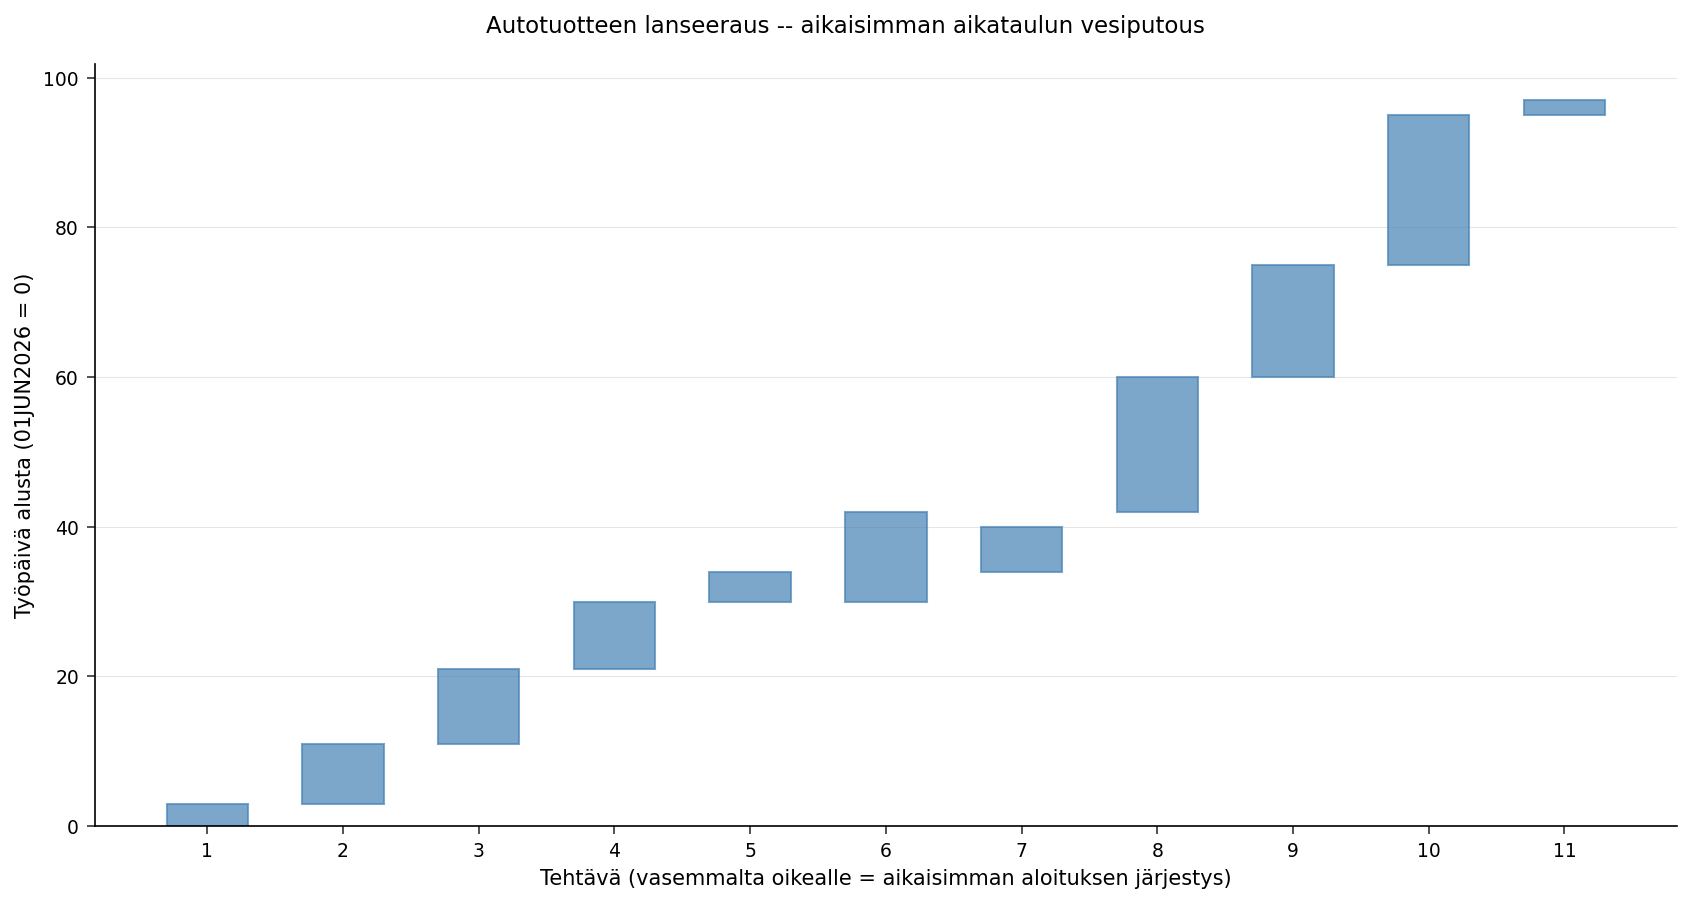

In [8]:
TIEDOT gantt; ASETA sched_es;
   ord = es;          /* numeerinen x = aikaisimman aloituksen järjestys */
SUORITA;
PROSEDUURI LAJITTELE TIEDOT=gantt; MUKAAN ord activity; SUORITA;
TIEDOT gantt; ASETA gantt; ax = _n_; SUORITA;   /* tiivis 1..11 x-indeksi */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
OTSIKKO 'Autotuotteen lanseeraus -- aikaisimman aikataulun vesiputous';
PROSEDUURI SGPLOT TIEDOT=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS NIMIKE='Tehtävä (vasemmalta oikealle = aikaisimman aloituksen järjestys)'
         integer VALUES=(1 ASTI 11 MUKAAN 1);
   YAXIS NIMIKE='Työpäivä alusta (01JUN2026 = 0)' grid;
SUORITA;
ODS GRAPHICS OFF;

Vasemmalta oikealle luettuna palkit nousevat portaittain kriittistä ketjua ylös. Kaksi tehtävää, joiden palkit rikkovat portaikon -- alkaen matalammalta kuin edellisen palkin yläreuna -- ovat hintailmoitus ja hyväksyntä, toiminnot joilla on pelivaraa.

## Kokonaispelivara tehtävittäin

Kunkin tehtävän kokonaispelivaran piirtäminen tekee kriittisestä polusta erehtymättömän: jokainen kriittinen tehtävä on nollassa, ja vain kaksi sääntelytehtävää nousee sen yläpuolelle.

                                Kokonaispelivara tehtävittäin (0 = kriittisellä polulla)                                




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Kokonaispelivara tehtävittäin (0 = kriittisellä polulla).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


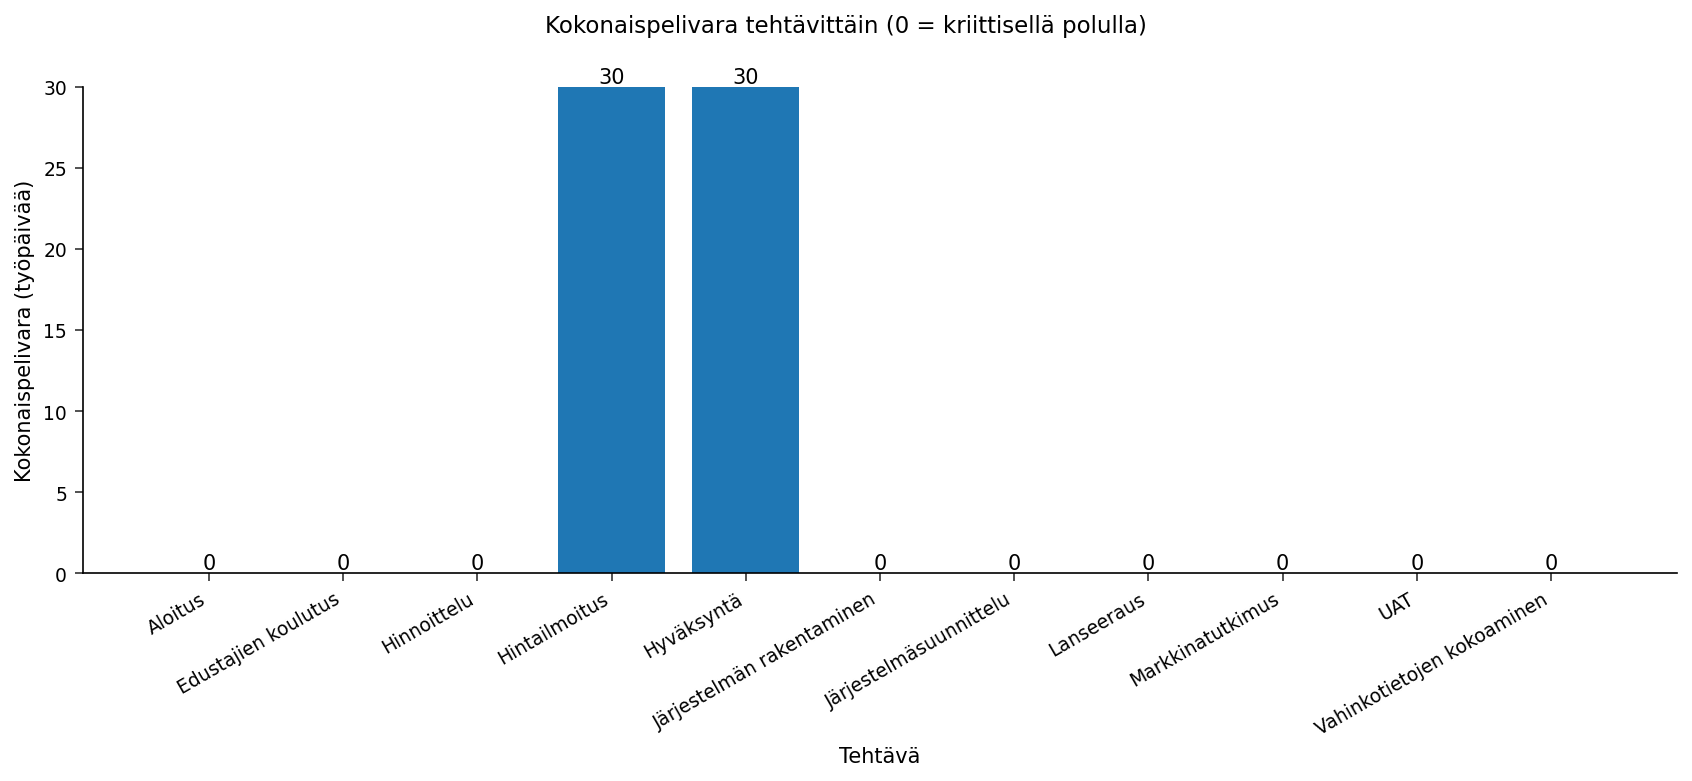

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
OTSIKKO 'Kokonaispelivara tehtävittäin (0 = kriittisellä polulla)';
PROSEDUURI SGPLOT TIEDOT=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS NIMIKE='Tehtävä' fitpolicy=rotatethin;
   YAXIS NIMIKE='Kokonaispelivara (työpäivää)';
SUORITA;
ODS GRAPHICS OFF;

## Resurssikuormitus aikaisimman aikataulun mukaan

Ajoituksen lisäksi suunnitelma kilpailee kahdesta erikoisosaajaryhmästä. Kunkin tehtävän laajentaminen sen kattamille työpäiville ja päivittäisen kysynnän summaaminen antaa resurssikuormitusprofiilin -- kuinka monta aktuaaria ja kehittäjää suunnitelma tarvitsee päivittäin, jos jokainen tehtävä alkaa mahdollisimman aikaisin. Huippu on suurin kapasiteetti, jonka ohjelma koskaan vaatii kerralla.

                             Päivittäisen resurssikuormituksen huippu (aikaisin aikataulu)                              

                                                  The MEANS Procedure

 Variable    Label            Maximum
 ------------------------------------
 ACTUARIES   Aktuaarit              3
 DEVELOPERS  Kehittäjät             3
 ------------------------------------

                      Aktuaarien ja kehittäjien päivittäinen kuormitus aikaisimmassa aikataulussa                       




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Päivittäisen resurssikuormituksen huippu (aikaisin aikataulu).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Aktuaarien ja kehittäjien päivittäinen kuormitus aikaisimmassa aikataulussa.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


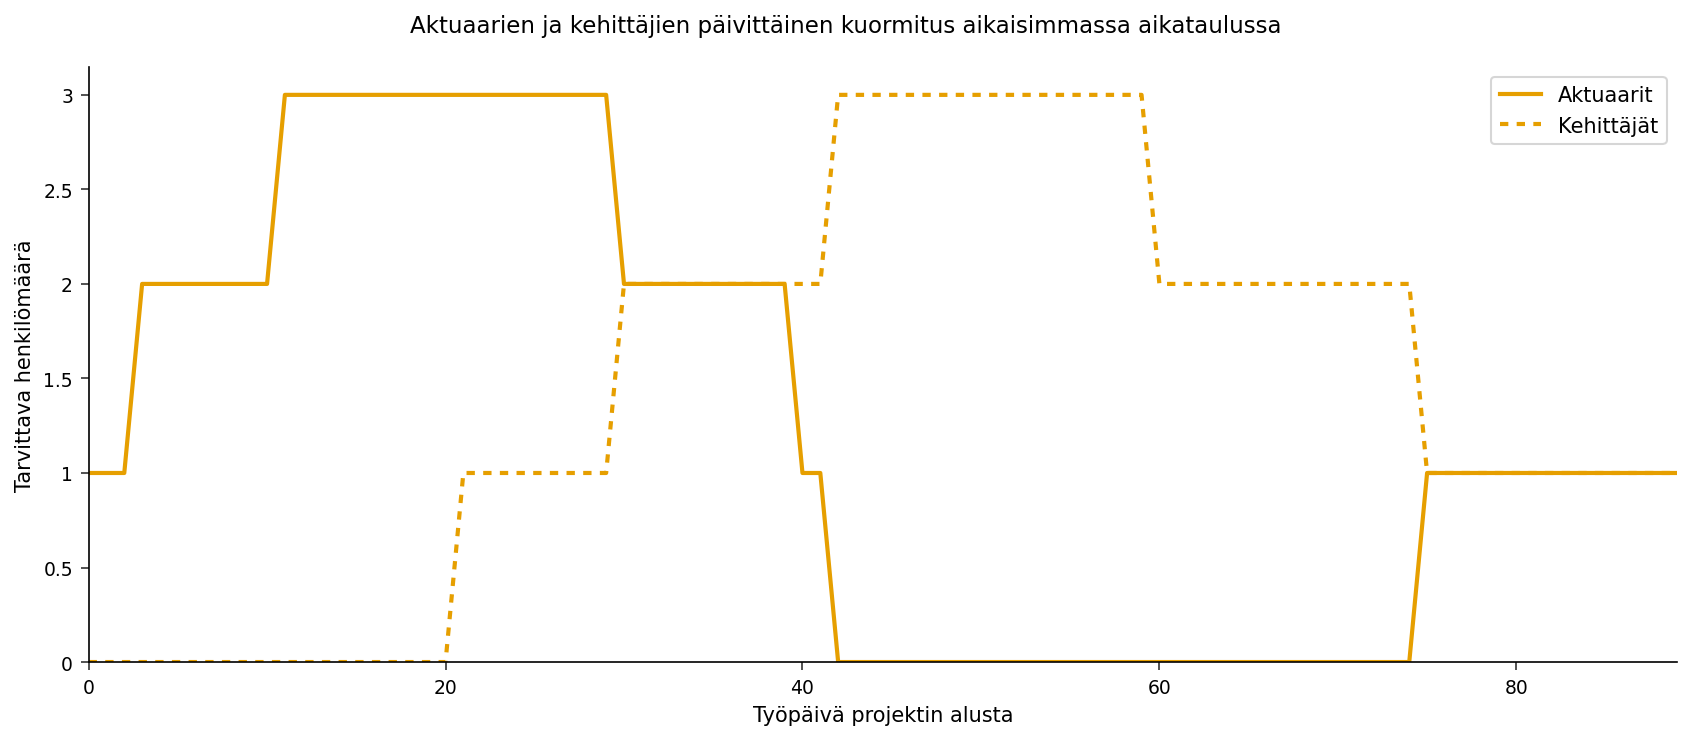

In [10]:
TIEDOT LOAD;
   ASETA sched;
   TEE d = es ASTI ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      TULOSTE;
   LOPPU;
   SÄILYTÄ day a_use d_use;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=LOAD NOPRINT NWAY;
   LUOKKA day;
   MUUTTUJA a_use d_use;
   TULOSTE out=rprofile(POISTA=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
SUORITA;
PROSEDUURI LAJITTELE TIEDOT=rprofile; MUKAAN day; SUORITA;

OTSIKKO 'Päivittäisen resurssikuormituksen huippu (aikaisin aikataulu)';
PROSEDUURI KESKIARVOT TIEDOT=rprofile MAX maxdec=0;
   MUUTTUJA actuaries developers;
   NIMIKE actuaries='Aktuaarit' developers='Kehittäjät';
SUORITA;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
OTSIKKO 'Aktuaarien ja kehittäjien päivittäinen kuormitus aikaisimmassa aikataulussa';
PROSEDUURI SGPLOT TIEDOT=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Aktuaarit';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Kehittäjät';
   XAXIS NIMIKE='Työpäivä projektin alusta';
   YAXIS NIMIKE='Tarvittava henkilömäärä' MIN=0;
   keylegend / location=inside position=topright;
SUORITA;
ODS GRAPHICS OFF;

## Tulosten tulkinta

- **Lanseerauspäivän määrää rakennushaara, ei sääntelyhaara.** Kriittinen polku kulkee Aloitus -> Markkinatutkimus -> Vahinkotietojen kokoaminen -> Hinnoittelu -> Järjestelmäsuunnittelu -> Järjestelmän rakentaminen -> UAT -> Edustajien koulutus -> Lanseeraus, kokonaiskestona 97 työpäivää (valmistuen 13OCT2026). Jokaisen näistä tehtävistä pelivara on nolla, joten mikä tahansa viive niissä työntää lanseerausta päivä päivältä.

- **Sääntelyhaaralla on kuukauden väljyys.** Hintailmoituksella ja hyväksynnällä on kummallakin 30 työpäivän kokonaispelivara. Hinnoittelun valmistuttua ne voivat alkaa myöhäisimpänä myöhäisimmän aloituksen päivämääränään ja silti yhtyä edustajien koulutukseen ajallaan, koska rinnakkainen järjestelmän rakennushaara (järjestelmäsuunnittelu -> järjestelmän rakentaminen -> UAT) on kahdesta lanseeraukseen syöttävästä polusta pidempi. Suunnittelun kannalta ilmoitus *ei* ole tässä sitova rajoite -- vaan vakuutusjärjestelmän rakentaminen on.

- **Erikoisosaajien kysyntä huipentuu eri vaiheissa.** Kuormitusprofiili osoittaa, että aktuaarien kysyntä huipentuu aikaisin (hinnoitteluun asti) ja kehittäjien kysyntä myöhemmin (järjestelmän rakentamiseen asti), kumpikin enintään kolme henkilöä päivässä. Koska kaksi huippua osuvat eri vaiheisiin, pieni, peräkkäin toimiva erikoisosaajaryhmä voi miehittää suunnitelman -- ohjelma ei tarvitse suurinta aktuaari- ja kehittäjämääräänsä samanaikaisesti.

**Liiketoiminnallinen johtopäätös.** CPM muuntaa lanseeraustehtävien luettelon toimintakelpoiseksi aikatauluksi: se tunnistaa rakennushaaran toiminnot, jotka vakuutusyhtiön on suojattava saavuttaakseen 13OCT2026-tavoitteen, kvantifioi sääntelyilmoituksessa käytettävissä olevan kuukauden väljyyden ja osoittaa, että porrastetut aktuaari- ja kehittäjähuiput sallivat vähäisen erikoisosaajaryhmän toteuttaa suunnitelman.

*Toteutushuomautus:* SAS laskee tämän PROC CPM -proseduurilla (SAS/OR). Jenner saavuttaa saman eteen-/taaksepäin kriittisen polun tuloksen PROC OPTMODEL -proseduurilla ratkaisemalla kaksi pisimmän polun lineaarista optimointitehtävää, jotka ovat menetelmän perustana.